# Forest Plot: Effect of Cuisine Group on Inspection SCORE

Pure visualization notebook: loads the coefficient table and model-ready data saved by `02_analysis.ipynb` (which fits one shared OLS model of SCORE on cuisine group, restaurant-name keywords, and zip-code income quartile) and draws the cuisine-group slice of that model. See `03b_keyword_forest_plot.ipynb` and `03c_income_forest_plot.ipynb` for the other two predictor groups.

**Takes in:** `output/shared_model_coefficients.csv`, `data/model_ready_inspections.csv` (both written by `02_analysis.ipynb`)

**Outputs:** `output/forest_plot_cuisine.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import utils

## Load saved model results

In [2]:
coef_table = utils.load_model_coefficients()
model_ready = pd.read_csv(utils.MODEL_READY_PATH)
print(f"Loaded {len(coef_table)} model coefficients and {len(model_ready):,} model-ready rows")

Loaded 27 model coefficients and 131,466 model-ready rows


## Forest plot: cuisine group

Coefficients (95% CI) for the 6 non-reference cuisine groups vs. the reference group ("American & Southern"), sorted by absolute effect size. Blue = higher SCORE (worse), red = lower SCORE (better).

Saved forest plot to /Users/ethan/qss20-nyc-restaurant-inspections/output/forest_plot_cuisine.png


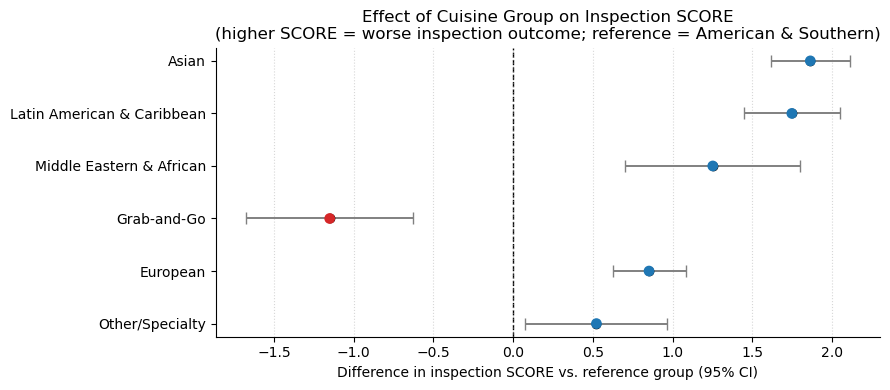

,label,coef,ci_low,ci_high,abs_coef
0,Other/Specialty,0.522548,0.076782,0.968314,0.522548
1,European,0.852421,0.623424,1.081418,0.852421
2,Grab-and-Go,-1.150407,-1.675124,-0.625690,1.150407
3,Middle Eastern & African,1.252317,0.702531,1.802104,1.252317
4,Latin American & Caribbean,1.748195,1.447510,2.048880,1.748195
5,Asian,1.864169,1.616524,2.111814,1.864169


In [3]:
utils.forest_plot(
    coef_table,
    prefix="cuisine_group_",
    label_fn=lambda n: n.replace("cuisine_group_", ""),
    title="Effect of Cuisine Group on Inspection SCORE\n"
          "(higher SCORE = worse inspection outcome; reference = American & Southern)",
    save_path=f"{utils.OUTPUT_DIR}/forest_plot_cuisine.png",
)